<a href="https://colab.research.google.com/github/manideep52563-art/CodeAlpha_MachineLearning_Tasks/blob/main/Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if 'heart.csv' in files:
        print("FOUND!")
        print(os.path.join(root, 'heart.csv'))

FOUND!
/content/drive/MyDrive/Disease_prediction_Project /heart.csv


In [3]:
import pandas as pd

file_path = "/content/drive/MyDrive/Disease_prediction_Project /heart.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Display all column names
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\n" + "="*50)

# Dataset information
print("DATASET INFORMATION:")
df.info()

print("\n" + "="*50)

# Check missing values
print("MISSING VALUES:")
print(df.isnull().sum())

print("\n" + "="*50)

# Statistical summary
print("STATISTICAL SUMMARY:")
display(df.describe())

COLUMN NAMES:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

MISSING VALUES:
age         0
sex         0
cp          0
t

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Remove duplicate rows
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 1
Shape after removing duplicates: (302, 14)


In [6]:
# Check target distribution
print("Target distribution:")
print(df["target"].value_counts())

Target distribution:
target
1    164
0    138
Name: count, dtype: int64


In [7]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


In [8]:
print("Columns and Data Types:\n")
print(df.dtypes)

Columns and Data Types:

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


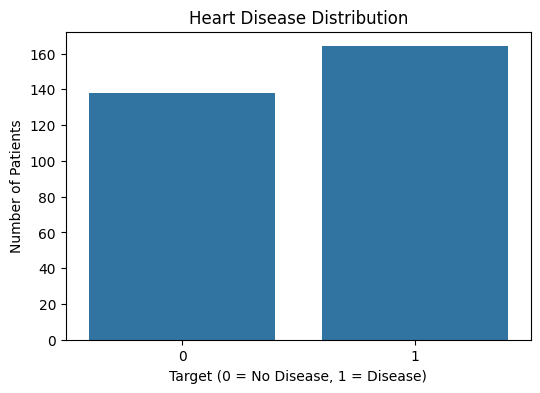

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")

plt.show()

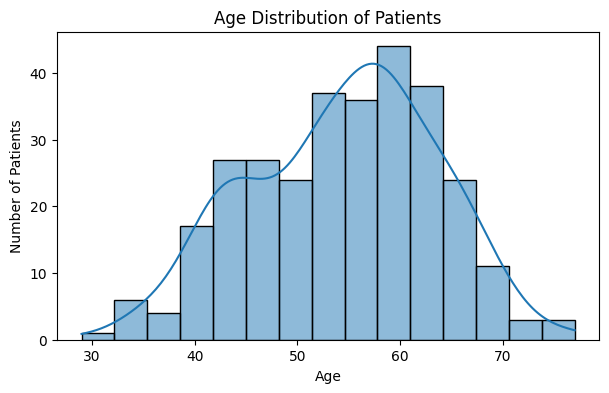

In [10]:
plt.figure(figsize=(7,4))

sns.histplot(data=df, x="age", bins=15, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

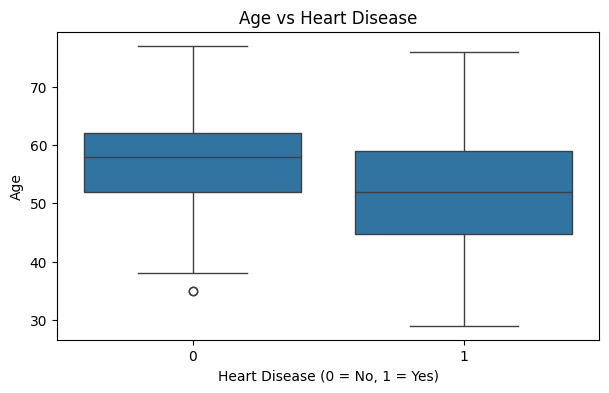

In [11]:
plt.figure(figsize=(7,4))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

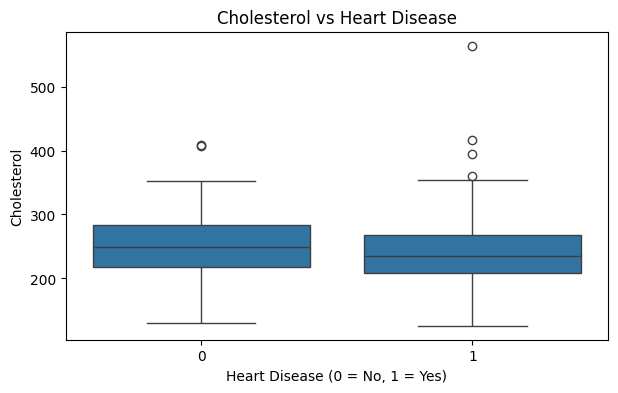

In [12]:
plt.figure(figsize=(7,4))

sns.boxplot(x="target", y="chol", data=df)

plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol")

plt.show()

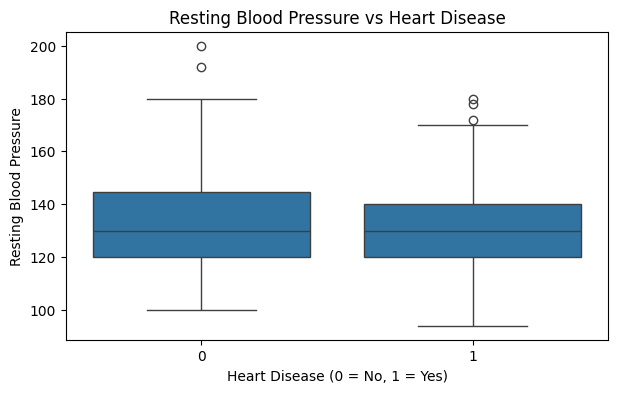

In [13]:
plt.figure(figsize=(7,4))

sns.boxplot(x="target", y="trestbps", data=df)

plt.title("Resting Blood Pressure vs Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Resting Blood Pressure")

plt.show()

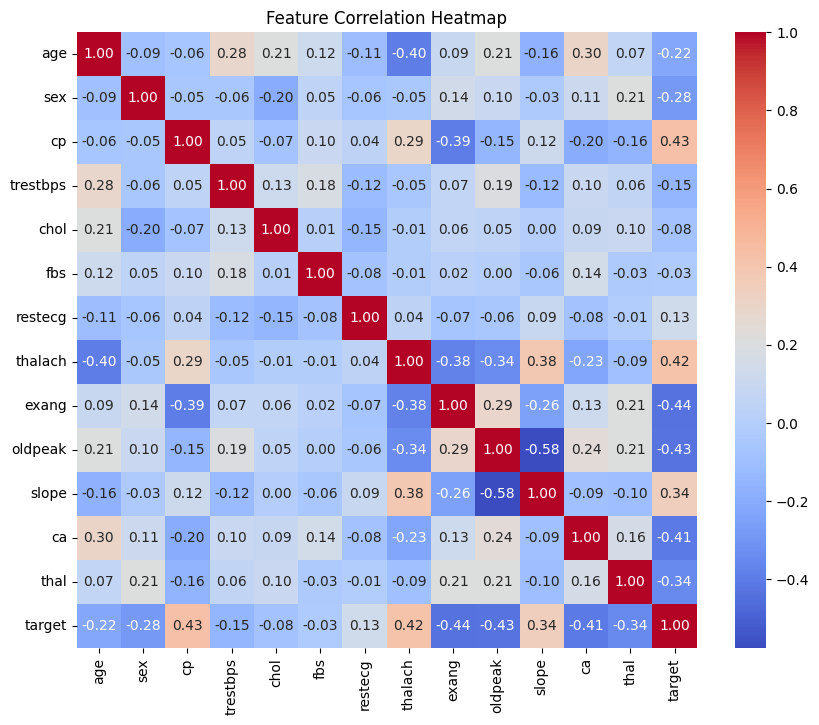

In [14]:
plt.figure(figsize=(10,8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Training data: (241, 13)
Testing data: (61, 13)
Feature scaling completed successfully!


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1. Logistic Regression
# -----------------------------
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)


# -----------------------------
# 2. Support Vector Machine
# -----------------------------
svm_model = SVC(kernel="rbf", probability=True, random_state=42)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)


# -----------------------------
# 3. Random Forest
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=6
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


print("All 3 models trained successfully! ✅")

All 3 models trained successfully! ✅


In [17]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, logistic_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("MODEL ACCURACY")
print("-" * 35)

print(f"Logistic Regression : {logistic_accuracy * 100:.2f}%")
print(f"SVM                 : {svm_accuracy * 100:.2f}%")
print(f"Random Forest       : {rf_accuracy * 100:.2f}%")

MODEL ACCURACY
-----------------------------------
Logistic Regression : 78.69%
SVM                 : 83.61%
Random Forest       : 80.33%


In [18]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy,Accuracy (%)
1,SVM,0.836066,83.606557
2,Random Forest,0.803279,80.327869
0,Logistic Regression,0.786885,78.688525


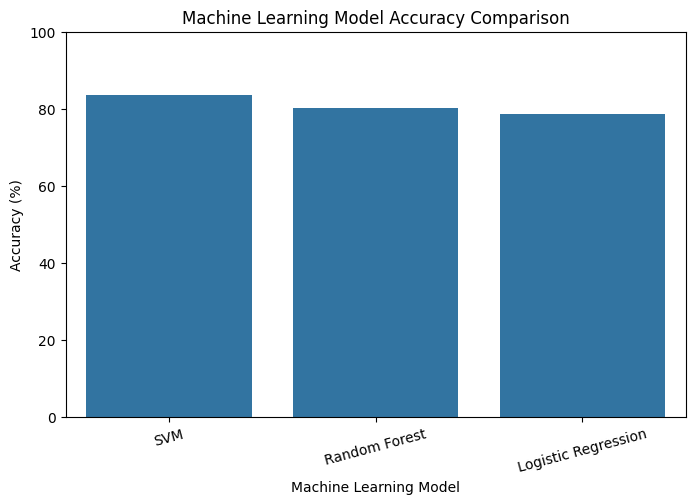

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=15)
plt.show()

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": logistic_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred
}

evaluation = []

for name, prediction in models.items():

    evaluation.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction)
    })

evaluation_df = pd.DataFrame(evaluation)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.786885,0.763158,0.878788,0.816901
1,SVM,0.836066,0.794872,0.939394,0.861111
2,Random Forest,0.803279,0.756098,0.939394,0.837838


SVM Confusion Matrix:
[[20  8]
 [ 2 31]]


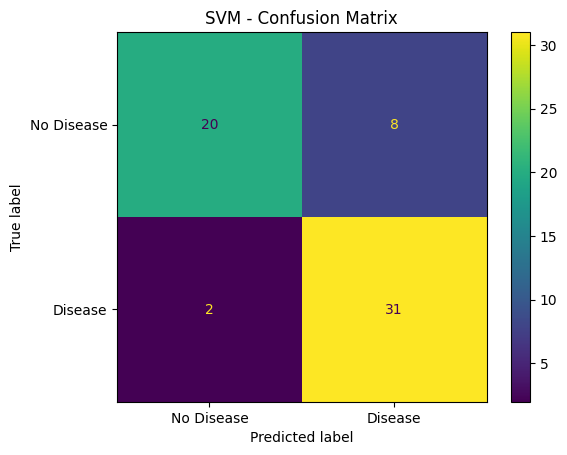

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Confusion Matrix for SVM
cm = confusion_matrix(y_test, svm_pred)

print("SVM Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
).plot()

plt.title("SVM - Confusion Matrix")
plt.show()

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("SVM Classification Report")
print("=" * 40)

print(classification_report(
    y_test,
    svm_pred,
    target_names=["No Disease", "Disease"]
))

SVM Classification Report
              precision    recall  f1-score   support

  No Disease       0.91      0.71      0.80        28
     Disease       0.79      0.94      0.86        33

    accuracy                           0.84        61
   macro avg       0.85      0.83      0.83        61
weighted avg       0.85      0.84      0.83        61



In [23]:
print("Features used by the model:")
print(X.columns.tolist())

Features used by the model:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [25]:
# ==========================================
# HEART DISEASE PATIENT PREDICTION
# ==========================================

# Patient details
age = 52
sex = 1
cp = 2
trestbps = 140
chol = 250
fbs = 0
restecg = 1
thalach = 150
exang = 0
oldpeak = 1.2
slope = 1
ca = 0
thal = 2

# Put values in the EXACT feature order
patient_data = [
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
]

# Convert to DataFrame
patient_df = pd.DataFrame(
    [patient_data],
    columns=X.columns
)

# Scale input using the same scaler used during training
patient_scaled = scaler.transform(patient_df)

# Predict using SVM
prediction = svm_model.predict(patient_scaled)[0]

# Get prediction probabilities
probability = svm_model.predict_proba(patient_scaled)[0]

# Display result
print("=" * 50)
print("       HEART DISEASE PREDICTION SYSTEM")
print("=" * 50)

print("\nPatient Information")
print("-" * 30)
print("Age              :", age)
print("Sex              :", sex)
print("Chest Pain Type  :", cp)
print("Blood Pressure   :", trestbps)
print("Cholesterol      :", chol)
print("Max Heart Rate   :", thalach)

print("\nPrediction")
print("-" * 30)

if prediction == 1:
    print("⚠️ Result: HIGHER RISK OF HEART DISEASE")
else:
    print("✅ Result: LOWER RISK OF HEART DISEASE")

print(f"Model Confidence: {probability[prediction] * 100:.2f}%")

print("=" * 50)

       HEART DISEASE PREDICTION SYSTEM

Patient Information
------------------------------
Age              : 52
Sex              : 1
Chest Pain Type  : 2
Blood Pressure   : 140
Cholesterol      : 250
Max Heart Rate   : 150

Prediction
------------------------------
⚠️ Result: HIGHER RISK OF HEART DISEASE
Model Confidence: 89.32%


In [26]:
# ==========================================
# INTERACTIVE HEART DISEASE PREDICTION
# ==========================================

print("=" * 55)
print("       HEART DISEASE PREDICTION SYSTEM")
print("=" * 55)

# Patient input
age = float(input("Enter Age: "))
sex = int(input("Enter Sex (0 = Female, 1 = Male): "))
cp = int(input("Enter Chest Pain Type (0-3): "))
trestbps = float(input("Enter Resting Blood Pressure: "))
chol = float(input("Enter Cholesterol: "))
fbs = int(input("Enter Fasting Blood Sugar (0 = No, 1 = Yes): "))
restecg = int(input("Enter Resting ECG (0-2): "))
thalach = float(input("Enter Maximum Heart Rate: "))
exang = int(input("Enter Exercise Induced Angina (0 = No, 1 = Yes): "))
oldpeak = float(input("Enter ST Depression (oldpeak): "))
slope = int(input("Enter Slope (0-2): "))
ca = int(input("Enter Number of Major Vessels (0-4): "))
thal = int(input("Enter Thal Value (0-3): "))

# Create patient data
patient_data = [[
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
]]

# Convert to DataFrame
patient_df = pd.DataFrame(
    patient_data,
    columns=X.columns
)

# Scale patient data
patient_scaled = scaler.transform(patient_df)

# Prediction
prediction = svm_model.predict(patient_scaled)[0]

# Probability
probability = svm_model.predict_proba(patient_scaled)[0]

# Result
print("\n" + "=" * 55)
print("                PREDICTION RESULT")
print("=" * 55)

if prediction == 1:
    print("⚠️ HIGHER RISK OF HEART DISEASE")
else:
    print("✅ LOWER RISK OF HEART DISEASE")

print(f"\nModel Confidence: {probability[prediction] * 100:.2f}%")

print("=" * 55)

       HEART DISEASE PREDICTION SYSTEM
Enter Age: 68
Enter Sex (0 = Female, 1 = Male): 1
Enter Chest Pain Type (0-3): 1
Enter Resting Blood Pressure: 160
Enter Cholesterol: 180
Enter Fasting Blood Sugar (0 = No, 1 = Yes): 1
Enter Resting ECG (0-2): 1
Enter Maximum Heart Rate: 160
Enter Exercise Induced Angina (0 = No, 1 = Yes): 1
Enter ST Depression (oldpeak): 2.5
Enter Slope (0-2): 1
Enter Number of Major Vessels (0-4): 2
Enter Thal Value (0-3): 2

                PREDICTION RESULT
✅ LOWER RISK OF HEART DISEASE

Model Confidence: 85.88%
Note: This is an ML prediction prototype,
not a medical diagnosis.
